In [5]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure local package import works when notebook is run from this folder
sys.path.append("../../")

# Import only core modules to avoid optional dependencies in package-level imports
from pyepidemics.models.model import CompartmentalModel
from pyepidemics.params.optimizer import ParamsOptimizer

In [6]:
data_path_csv = Path("../../data/shanghai/seir_data.csv")
data_path_CSV = Path("../../data/shanghai/seir_data.CSV")

data_path = data_path_csv if data_path_csv.exists() else data_path_CSV
seir_data = pd.read_csv(data_path)

# Build observation table used for fitting
seir_data["日期"] = pd.to_datetime(seir_data["日期"])
seir_data = seir_data.sort_values("日期")

obs = (
    seir_data.set_index("日期")[["潜伏者_E", "传染者_I"]]
    .rename(columns={"潜伏者_E": "E", "传染者_I": "I"})
)

init_state = {
    "S": float(seir_data.iloc[0]["有效易感数_S"]),
    "E": float(seir_data.iloc[0]["潜伏者_E"]),
    "I": float(seir_data.iloc[0]["传染者_I"]),
    "R": float(seir_data.iloc[0]["移除者_R"]),
}

obs.head()

,E,I
日期,,
2017-05-15,535,0
2017-05-16,737,357
2017-05-17,831,729
2017-05-18,886,1040
2017-05-19,933,1284


Parameters Optimization:   0%|          | 0/10000 [00:00<?, ?it/s]

... Early stopping - best value has not changed since 100 trials at 0.2447006578217008
... Found best solution {'beta': 0.8579778890300107, 'sigma': 1.1613112937811108, 'gamma': 0.7697576435552625} for value 0.2447006578217008
Best params: {'beta': 0.8579778890300107, 'sigma': 1.1613112937811108, 'gamma': 0.7697576435552625}
Best loss: 0.2447006578217008
Estimated R0: 1.115


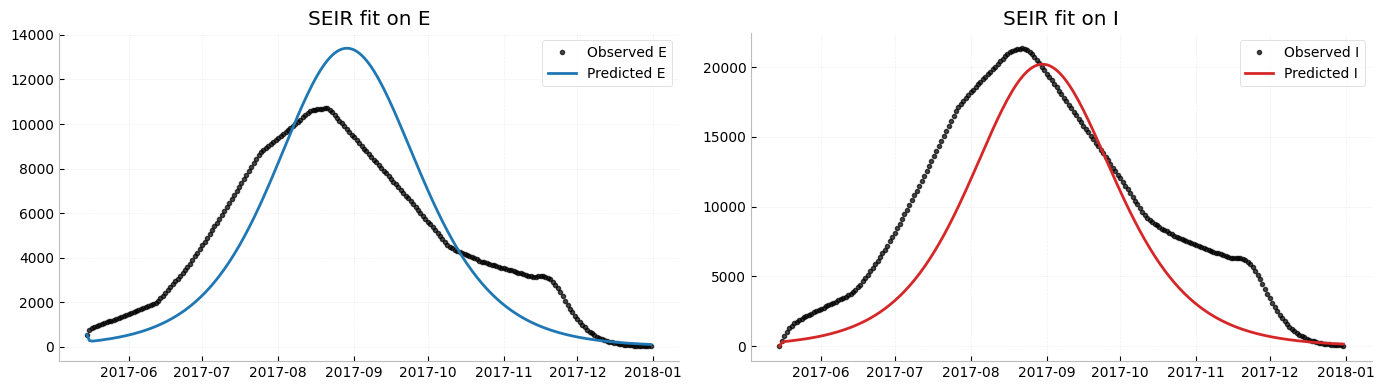

In [7]:
class FittableSEIR(CompartmentalModel):
    def __init__(self, N):
        self.N = float(N)
        self.best_params = None
        self.reset({"beta": 0.40, "sigma": 1 / 1.5, "gamma": 1 / 3.0})

    def reset(self, params):
        self.best_params = params
        beta = float(params["beta"])
        sigma = float(params["sigma"])
        gamma = float(params["gamma"])

        compartments = ["S", "E", "I", "R"]
        super().__init__(compartments, initial_state="S", start_state="E")

        self.beta = self.make_callable(beta)
        self.sigma = self.make_callable(sigma)
        self.gamma = self.make_callable(gamma)

        self.add_transition(
            "S",
            "E",
            lambda y, t: self.beta(y, t) * y["S"] * y["I"] / self.N,
        )
        self.add_transition("E", "I", lambda y, t: self.sigma(y, t) * y["E"])
        self.add_transition("I", "R", lambda y, t: self.gamma(y, t) * y["I"])

    def r0(self):
        beta = float(self.best_params["beta"])
        gamma = float(self.best_params["gamma"])
        return beta / gamma


N_eff = float(sum(init_state.values()))
model = FittableSEIR(N=N_eff)

# Search space for parameter fitting
space = {
    "beta": (0.15, 1.20),
    "sigma": (0.20, 1.20),
    "gamma": (0.10, 0.80),
}

# Explicitly use the optimizer in pyepidemics/params/optimizer.py
opt = ParamsOptimizer(model)
best = opt.run(
    true=obs,
    space=space,
    init_state=init_state,
    n=10000,
    early_stopping=100,
    save=False,
    show_progress_bar=True,
    info={"city": "Shanghai", "pathogen": "H3N2"},
)

model.reset(best)
pred = model.predict(obs, init_state=init_state)

print("Best params:", best)
print("Best loss:", opt.study.best_value)
print("Estimated R0:", round(model.r0(), 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(obs.index, obs["E"], "k.", label="Observed E", alpha=0.7)
axes[0].plot(pred.index, pred["E"], "tab:blue", label="Predicted E")
axes[0].set_title("SEIR fit on E")
axes[0].legend()

axes[1].plot(obs.index, obs["I"], "k.", label="Observed I", alpha=0.7)
axes[1].plot(pred.index, pred["I"], "tab:red", label="Predicted I")
axes[1].set_title("SEIR fit on I")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

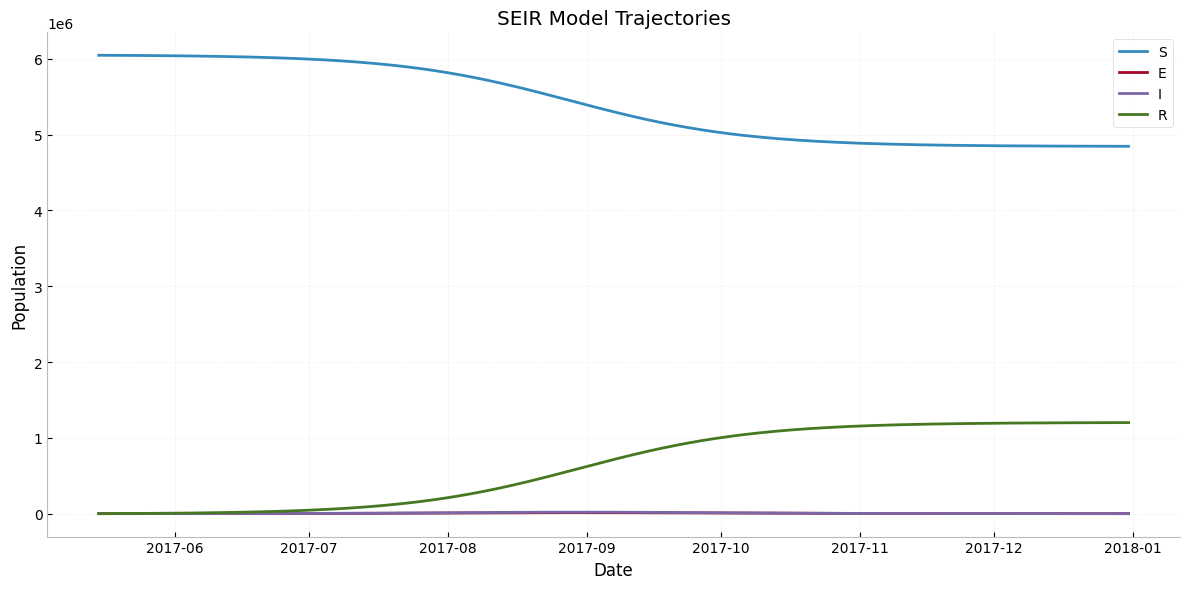

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pred.index, pred["S"], label="S")
ax.plot(pred.index, pred["E"], label="E")
ax.plot(pred.index, pred["I"], label="I")
ax.plot(pred.index, pred["R"], label="R")

ax.set_title("SEIR Model Trajectories")
ax.set_xlabel("Date")
ax.set_ylabel("Population")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()